We'll use these features:
population

gdp

primary_energy_consumption

renewables_consumption

coal_consumption

gas_consumption

oil_consumption


Target:
High_Electricity

In [1]:
# Green Skill Assignment
# Dataset : OWID Energy Dataset
# ==========================================================

# ==========================================================
# Import Libraries
# ==========================================================

# Definition:
# Libraries are used for data analysis,
# visualization and machine learning.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("owid-energy-data.csv")

print("Dataset Imported Successfully")

Dataset Imported Successfully


In [3]:
print(df.head())

         country  year iso_code  population  gdp  biofuel_cons_change_pct  \
0  ASEAN (Ember)  2000      NaN         NaN  NaN                      NaN   
1  ASEAN (Ember)  2001      NaN         NaN  NaN                      NaN   
2  ASEAN (Ember)  2002      NaN         NaN  NaN                      NaN   
3  ASEAN (Ember)  2003      NaN         NaN  NaN                      NaN   
4  ASEAN (Ember)  2004      NaN         NaN  NaN                      NaN   

   biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
0                      NaN                      NaN                  NaN   
1                      NaN                      NaN                  NaN   
2                      NaN                      NaN                  NaN   
3                      NaN                      NaN                  NaN   
4                      NaN                      NaN                  NaN   

   biofuel_elec_per_capita  ...  solar_share_elec  solar_share_energy  \
0      

In [4]:
print(df.tail())

        country  year iso_code  population           gdp  \
23372  Zimbabwe  2020      ZWE  15526887.0  2.317871e+10   
23373  Zimbabwe  2021      ZWE  15797220.0  2.514009e+10   
23374  Zimbabwe  2022      ZWE  16069061.0  2.590159e+10   
23375  Zimbabwe  2023      ZWE  16340829.0           NaN   
23376  Zimbabwe  2024      ZWE  16634366.0           NaN   

       biofuel_cons_change_pct  biofuel_cons_change_twh  \
23372                      NaN                      0.0   
23373                      NaN                      0.0   
23374                      NaN                      0.0   
23375                      NaN                      0.0   
23376                      NaN                      0.0   

       biofuel_cons_per_capita  biofuel_consumption  biofuel_elec_per_capita  \
23372                      0.0                  0.0                    6.440   
23373                      0.0                  0.0                    6.963   
23374                      0.0              

In [5]:
print(df.describe())

               year    population           gdp  biofuel_cons_change_pct  \
count  23377.000000  1.889400e+04  1.178000e+04              2070.000000   
mean    1976.238611  1.058587e+08  4.257565e+11                43.478804   
std       35.331092  4.720948e+08  3.507870e+12               286.672317   
min     1900.000000  1.776000e+03  1.642060e+08              -100.000000   
25%     1949.000000  1.599088e+06  1.426394e+10                -0.968000   
50%     1985.000000  6.951653e+06  4.357680e+10                 6.695500   
75%     2005.000000  2.581793e+07  1.830576e+11                23.320750   
max     2025.000000  8.231613e+09  1.301126e+14              6373.062000   

       biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
count              7903.000000              6338.000000          8057.000000   
mean                  1.054261                55.157113            15.092054   
std                   6.641947               180.660550            75.94252

In [6]:
# ==========================================================
# Report Understanding
# ==========================================================

print("""

Dataset Understanding

The dataset contains yearly records
of countries including

Population

GDP

Energy Consumption

Renewable Energy

Carbon Emissions

Electricity Generation

The objective is to classify
whether CO₂ emissions are
High or Low.

""")



Dataset Understanding

The dataset contains yearly records
of countries including

Population

GDP

Energy Consumption

Renewable Energy

Carbon Emissions

Electricity Generation

The objective is to classify
whether CO₂ emissions are
High or Low.




In [7]:
# ==========================================================
# Generalisation
# ==========================================================

# country
# Country Name

# year
# Observation Year

# population
# Total population

# gdp
# Gross Domestic Product

# primary_energy_consumption
# Total energy consumed

# electricity_generation
# Electricity generated

# renewables_consumption
# Renewable energy

# coal_consumption
# Coal usage

# gas_consumption
# Natural gas usage

# oil_consumption
# Oil usage

# co2
# Carbon dioxide emissions

In [8]:
# ==========================================================
# Relationship Between Features
# ==========================================================

# Population ↑
# Energy Consumption ↑

# GDP ↑
# Electricity Generation ↑

# Coal Consumption ↑
# CO₂ Emissions ↑

# Renewable Energy ↑
# CO₂ Emissions ↓

# Oil Consumption ↑
# CO₂ Emissions ↑

In [9]:
# ==========================================================
# Null Values
# ==========================================================

print(df.isnull().sum())

country                       0
year                          0
iso_code                   6112
population                 4483
gdp                       11597
                          ...  
wind_elec_per_capita      14972
wind_electricity          13870
wind_energy_per_capita    18232
wind_share_elec           15716
wind_share_energy         16998
Length: 130, dtype: int64


In [10]:
# ==========================================================
# Handle Null Values
# ==========================================================

numeric_columns = df.select_dtypes(include="number").columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].mean()
)

print(df.isnull().sum())

country                      0
year                         0
iso_code                  6112
population                   0
gdp                          0
                          ... 
wind_elec_per_capita         0
wind_electricity             0
wind_energy_per_capita       0
wind_share_elec              0
wind_share_energy            0
Length: 130, dtype: int64


In [11]:
# ==========================================================
# Handle Null Values
# ==========================================================

numeric_columns = df.select_dtypes(include="number").columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].mean()
)

print(df.isnull().sum())

country                      0
year                         0
iso_code                  6112
population                   0
gdp                          0
                          ... 
wind_elec_per_capita         0
wind_electricity             0
wind_energy_per_capita       0
wind_share_elec              0
wind_share_energy            0
Length: 130, dtype: int64


In [13]:
# ==========================================================
# Label Encoding
# ==========================================================

encoder = LabelEncoder()

df["country"] = encoder.fit_transform(df["country"])

print(df["country"].head())

0    0
1    0
2    0
3    0
4    0
Name: country, dtype: int64


In [14]:
# ==========================================================
# Scaling
# ==========================================================

scaler = StandardScaler()

scale_columns = [
    "population",
    "gdp",
    "primary_energy_consumption"
]

df[scale_columns] = scaler.fit_transform(
    df[scale_columns]
)

print(df[scale_columns].head())

     population  gdp  primary_energy_consumption
0 -3.511032e-17  0.0                         0.0
1 -3.511032e-17  0.0                         0.0
2 -3.511032e-17  0.0                         0.0
3 -3.511032e-17  0.0                         0.0
4 -3.511032e-17  0.0                         0.0


In [23]:
# ==========================================================
# Feature Engineering
# ==========================================================

median_value = df["electricity_generation"].median()

df["High_Electricity"] = np.where(
    df["electricity_generation"] > median_value,
    1,
    0
)

print(df[["electricity_generation", "High_Electricity"]].head())

   electricity_generation  High_Electricity
0                  378.76                 0
1                  405.09                 0
2                  433.19                 0
3                  458.30                 0
4                  496.61                 0


C:\Users\jayvi\AppData\Local\Temp\ipykernel_31848\2391607791.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["High_Electricity"] = np.where(


In [24]:
y = df["High_Electricity"]

In [25]:
X = df[[
    "population",
    "gdp",
    "primary_energy_consumption",
    "renewables_consumption",
    "coal_consumption",
    "gas_consumption",
    "oil_consumption"
]]

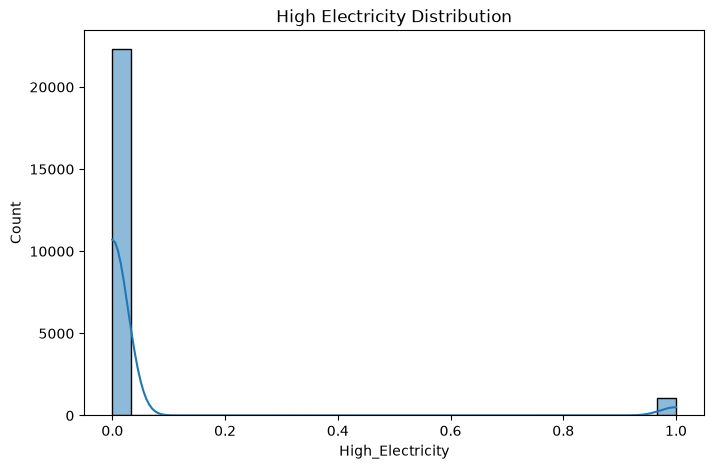

In [29]:
# ==========================================================
# Histogram
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["High_Electricity"],
    bins=30,
    kde=True
)

plt.title("High Electricity Distribution")

plt.show()

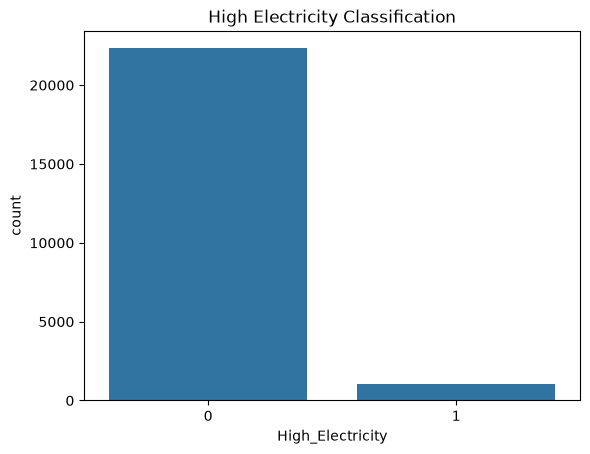

In [26]:
sns.countplot(
    x="High_Electricity",
    data=df
)

plt.title("High Electricity Classification")

plt.show()

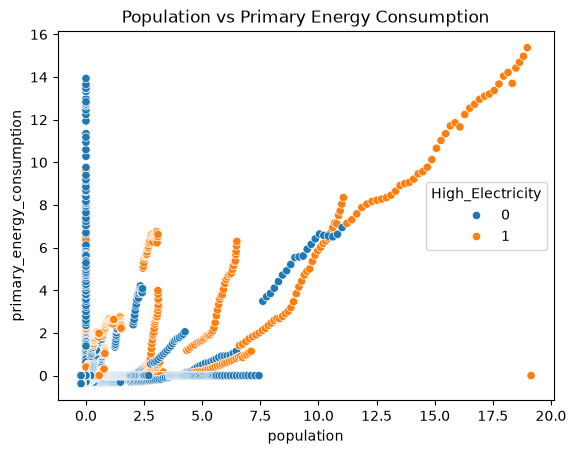

In [27]:
sns.scatterplot(
    x="population",
    y="primary_energy_consumption",
    hue="High_Electricity",
    data=df
)

plt.title("Population vs Primary Energy Consumption")

plt.show()

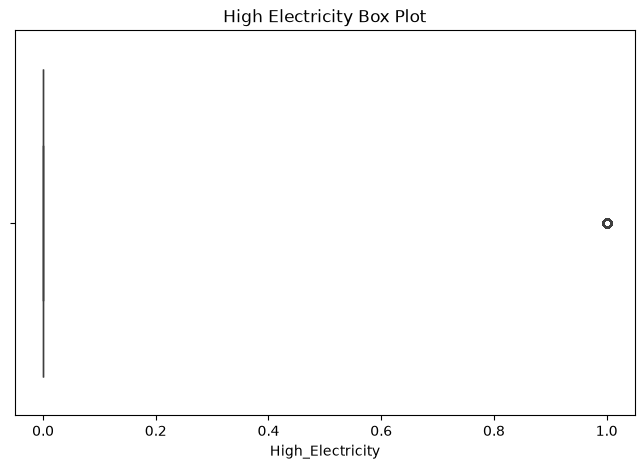

In [30]:
# ==========================================================
# Box Plot
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["High_Electricity"],
)

plt.title("High Electricity Box Plot")

plt.show()

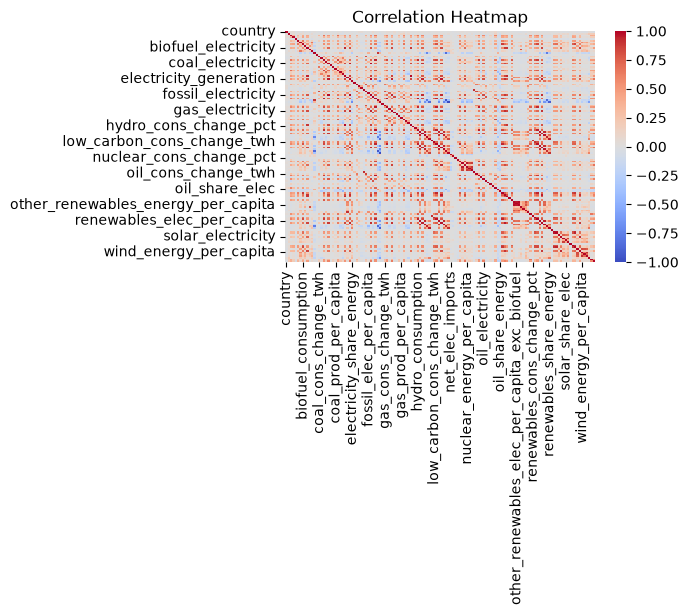

In [32]:
# ==========================================================
# Heatmap
# ==========================================================

plt.figure(figsize=(5,3))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [28]:
print("""

Insights

1. Electricity generation was converted into High and Low classes.

2. Logistic Regression predicts whether a country has high electricity generation.

3. Population and GDP influence electricity generation.

4. Renewable energy contributes to electricity production.

5. The model classifies countries into High Electricity and Low Electricity groups.

""")



Insights

1. Electricity generation was converted into High and Low classes.

2. Logistic Regression predicts whether a country has high electricity generation.

3. Population and GDP influence electricity generation.

4. Renewable energy contributes to electricity production.

5. The model classifies countries into High Electricity and Low Electricity groups.




Summary

• Imported the OWID Energy dataset using Pandas.
• Explored the dataset using head(), tail(), shape(), columns(), info() and describe().
• Studied important features and their relationships.
• Identified and handled missing values using the mean.
• Created a new feature (Energy_per_Person) through feature engineering.
• Applied Label Encoding to the categorical column.
• Scaled numerical columns using StandardScaler.
• Visualized the dataset using Seaborn plots such as Histogram, Scatter Plot,
  Box Plot, Count Plot and Heatmap.
• Split the dataset into training and testing sets.
• Built a Linear Regression model to predict primary energy consumption.
• Evaluated the model using MAE, MSE, RMSE and R² Score.
• Observed that energy consumption is influenced by factors such as
  population, GDP and different energy sources.